# FUTON Solvers

FUTON with a linear decoder is the paper's model: a basis along each axis, a CP
combiner and a linear decoder, both without bias, with an optional activation at
the output. On a grid its output is a CP tensor, linear in each factor matrix
and in the decoder when the others are held, so every block is a least-squares
problem whose two sides are small, and the model can be fitted by block
coordinate descent rather than by gradient descent. `nf.LeastSquares` solves
each block exactly, for any basis, and handles an output activation by refitting
Gauss-Newton targets every sweep; `nf.MultiplicativeUpdate` takes Lee and
Seung's step instead, which keeps a nonnegative model nonnegative. Both are
optimizers that `nf.train` takes in place of Adam, so a model is built and
trained the same way whichever fits it.

This notebook fits the linear FUTON to one Kodak image three ways: with Adam,
FUTON-Linear-Adam; by alternating least squares, FUTON-Linear-ALS; and, with hat
functions, by multiplicative updates, FUTON-Linear-MU. All run at the
benchmark's grid and parameter budget, next to the benchmark's model, the one
with a one-layer MLP decoder, trained by Adam: FUTON-MLP-Adam.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from PIL import Image

import neurofield as nf

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Load Image

Image size: 768 x 512


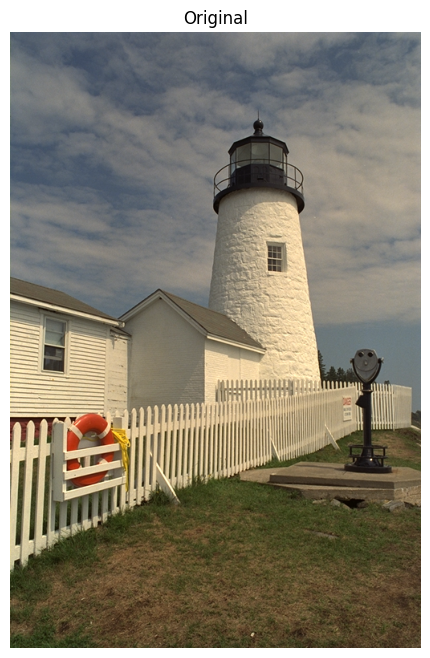

In [2]:
IMAGE_PATH = "../data/Kodak/kodim19.png"


img = Image.open(IMAGE_PATH)
W, H = img.size
print(f"Image size: {H} x {W}")
plt.figure(figsize=(6, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Original")
plt.show()

## Models

Every model has `(H/2, W/2)` basis functions per axis, the benchmark's grid, and
about 194k parameters. FUTON-MLP-Adam is the benchmark's model, at CP rank 224;
the linear models spend its decoder's 50k parameters on rank instead, 302.
FUTON-Linear-Adam has a sinc basis and a tanh at the output, and Adam trains it
at the benchmark's learning rate. FUTON-Linear-ALS is the same model fitted by
alternating least squares. FUTON-Linear-MU has hat functions, nonnegative and
left unnormalized so that they sum to one, and an affine output activation that
maps its nonnegative output onto the signal's range; multiplicative updates fit
it. Every model takes 2000 steps on a random 10 % of the pixels: an Adam step,
or one sweep over the blocks for the two solvers. A solver's `momentum`, 0.9
here and by default, averages each block's problem over the batches, and
`nf.train` anneals the newest batch's weight, `1 - momentum`, as it does
Adam's learning rate.

In [3]:
COMPONENTS = (H // 2, W // 2)
RANK = 224  # the benchmark's CP rank, under its one-layer MLP decoder
EPOCHS = 2000
SUBSAMPLE = 0.1  # the share of the pixels in a batch


def signed(z):
    """From [0, 1] to [-1, 1]: the output activation of a nonnegative model."""
    return 2 * z - 1


def futon(basis, decoder, rank, output_activation=torch.tanh, **basis_kwargs):
    return {
        "basis": (
            basis,
            {"num_components": COMPONENTS, "grid_size": (H, W), **basis_kwargs},
        ),
        "combiner": ("cp", {"rank": rank}),
        "decoder": decoder,
        "output_activation": output_activation,
    }


MLP = ("mlp", {"hidden_layers": 1})
LINEAR = ("linear", {"bias": False})  # the paper's decoder
BUDGET = nf.count_parameters(nf.FUTON(2, 3, **futon("sinc", MLP, RANK)))
# A linear decoder holds 3 R weights and a factor K_c R, so the rank that
# spends the budget on the grid is BUDGET / (K_1 + K_2 + 3).
LINEAR_RANK = BUDGET // (sum(COMPONENTS) + 3)

CONFIGS = [
    {  # the benchmark's model
        "name": "FUTON-MLP-Adam",
        "kwargs": futon("sinc", MLP, RANK),
        "optimizer": lambda model: torch.optim.Adam(model.parameters(), lr=3e-2),
    },
    {  # the paper's model, a CP model in the sinc basis, trained by Adam
        "name": "FUTON-Linear-Adam",
        "kwargs": futon("sinc", LINEAR, LINEAR_RANK),
        "optimizer": lambda model: torch.optim.Adam(model.parameters(), lr=3e-2),
    },
    {  # the same model, fitted by least squares
        "name": "FUTON-Linear-ALS",
        "kwargs": futon("sinc", LINEAR, LINEAR_RANK),
        "optimizer": lambda model: nf.LeastSquares(model, momentum=0.9),
    },
    {  # a nonnegative model, fitted by multiplicative updates
        "name": "FUTON-Linear-MU",
        "kwargs": futon("triangle", LINEAR, LINEAR_RANK, signed, normalize=False),
        "optimizer": lambda model: nf.MultiplicativeUpdate(model, momentum=0.9),
    },
]
print(f"Budget {BUDGET:,}: rank {LINEAR_RANK} for the linear models")

METRICS = {"psnr": nf.psnr, "ssim": nf.ssim, "lpips": nf.lpips}

Budget 194,435: rank 302 for the linear models


## Train

One call trains every model, with its own optimizer: Adam, whose learning rate
`nf.train` anneals, or a solver, which has none. Every hundredth step the model
is evaluated on all pixels; the time excludes these evaluations.

In [4]:
results = []
fitted = {}

for config in CONFIGS:
    torch.manual_seed(0)

    train_dataset = nf.ImageCoordinateDataset(IMAGE_PATH, subsample=SUBSAMPLE)
    eval_dataset = nf.ImageCoordinateDataset(IMAGE_PATH)

    model = nf.FUTON(in_features=2, out_features=3, **config["kwargs"])
    num_params = nf.count_parameters(model, trainable_only=False)

    print(f"\n--- {config['name']} ({num_params:,} params) ---")
    res = nf.train(
        model=model,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        optimizer=config["optimizer"](model),
        num_epochs=EPOCHS,
        metrics=METRICS,
        log_interval=EPOCHS // 20,
        eval_interval=EPOCHS // 20,
        device=device,
    )

    output = nf.chunked_inference(model, eval_dataset.input, device=device)
    recon = eval_dataset.postprocess(output.cpu())

    res["config"]["model"] = config["name"]
    res["reconstructed"] = recon
    results.append(res)
    fitted[config["name"]] = model

    del recon, res["model_dict"]
    torch.cuda.empty_cache()


--- FUTON-MLP-Adam (194,435 params) ---

--- FUTON-Linear-Adam (194,186 params) ---

--- FUTON-Linear-ALS (194,186 params) ---

--- FUTON-Linear-MU (194,186 params) ---


## Collect Results

In [5]:
records = []
for res in results:
    for entry in res["history"]:
        if "eval" not in entry:
            continue

        records.append(
            {
                "Model": res["config"]["model"],
                "# Params (k)": res["config"]["num_params"] / 1000,
                "Iteration": entry["epoch"],
                "Time (s)": entry["elapsed"],
                "PSNR (dB)": entry["eval"]["psnr"],
                "SSIM": entry["eval"]["ssim"],
                "LPIPS": entry["eval"]["lpips"],
            }
        )


records = pd.DataFrame(records)

## Convergence Performance

Every iteration sees a random 10 % of the pixels, so the left panel compares
the optimizers step for step and the right one, against time, by their cost.

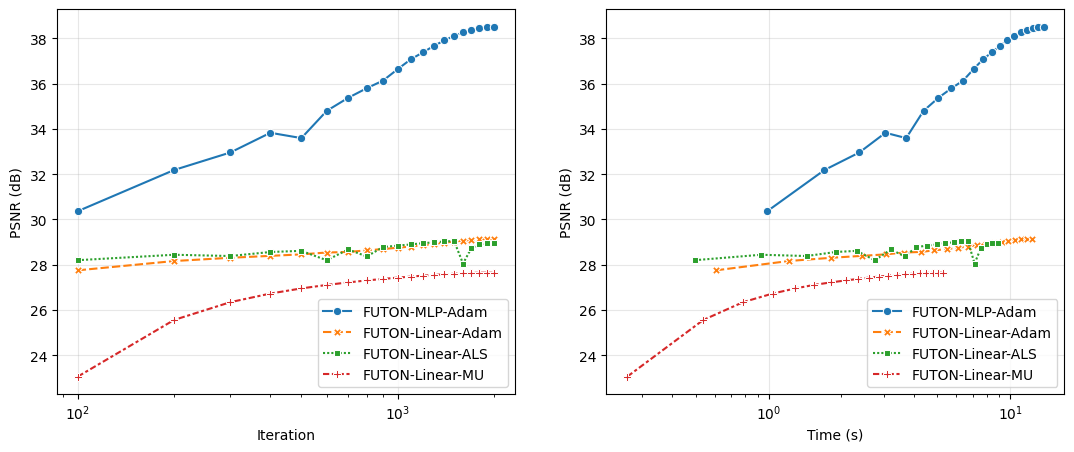

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(
    data=records,
    x="Iteration",
    y="PSNR (dB)",
    hue="Model",
    style="Model",
    markers=True,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="lower right")

sns.lineplot(
    data=records,
    x="Time (s)",
    y="PSNR (dB)",
    hue="Model",
    style="Model",
    markers=True,
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="lower right")

plt.show()

## Results Summary

In [7]:
summary = (
    records.groupby("Model")
    .agg(
        {
            "# Params (k)": "first",
            "Iteration": "last",
            "Time (s)": "last",
            "PSNR (dB)": "last",
            "SSIM": "last",
            "LPIPS": "last",
        }
    )
    .sort_values("PSNR (dB)", ascending=False)
    .reset_index()
)
display(summary)

,Model,# Params (k),Iteration,Time (s),PSNR (dB),SSIM,LPIPS
0,FUTON-MLP-Adam,194.435,2000,13.772063,38.523594,0.957647,0.100582
1,FUTON-Linear-Adam,194.186,2000,12.354675,29.139769,0.862058,0.220321
2,FUTON-Linear-ALS,194.186,2000,8.913603,28.981741,0.857939,0.231013
3,FUTON-Linear-MU,194.186,2000,5.267970,27.644758,0.816712,0.279421


With the same 2000 steps on a tenth of the pixels, least squares ends within
two tenths of a decibel of Adam on the same model, in about three quarters of
its time. Momentum is what lets it learn from minibatches: solved from a single
tenth of the image, a block would chase that tenth's noise, and the averaged
problem is the whole image's. The nonnegative hat-basis model ends a decibel
and a half lower in under half the time, and the MLP decoder is what separates
the benchmark's FUTON from all three linear models.

## Visual Comparison

The full image above a magnified region, with each model's PSNR over the whole
image.

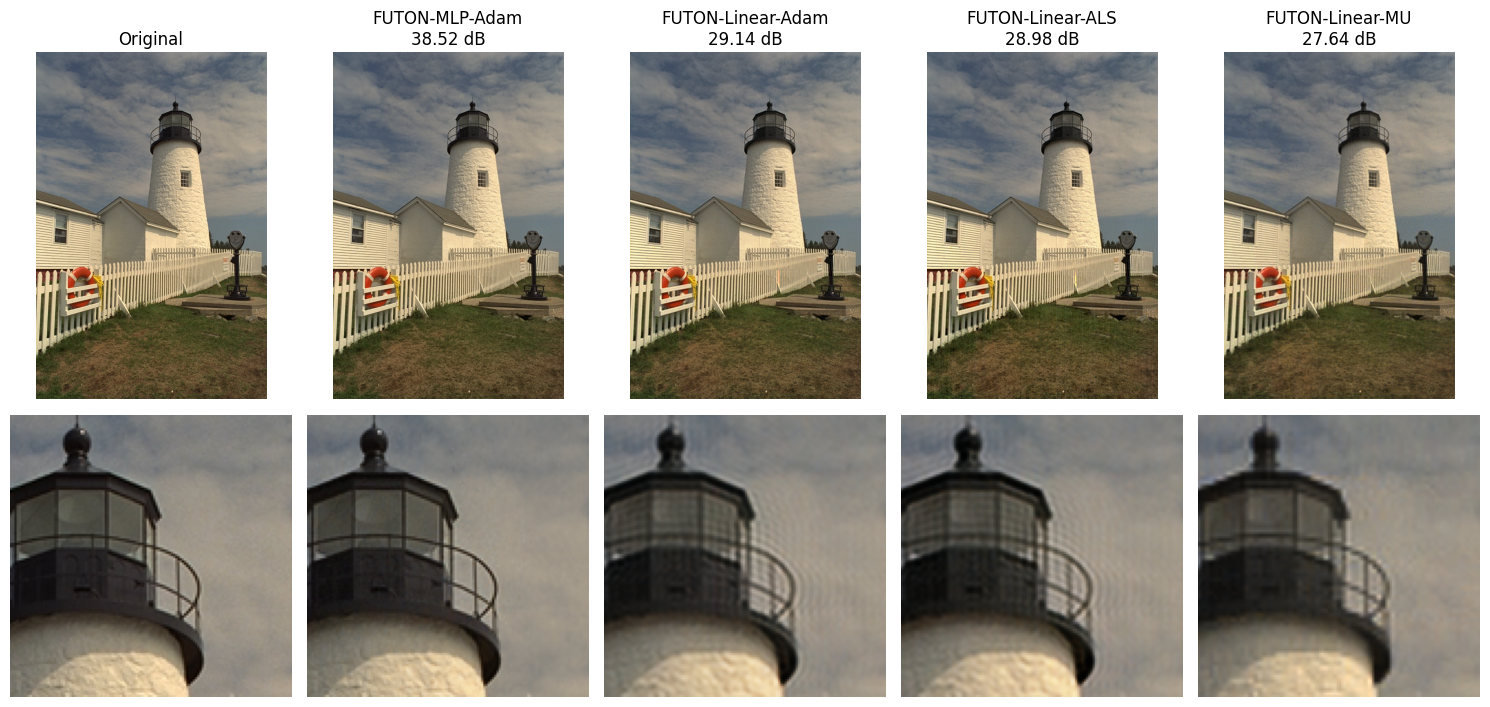

In [8]:
psnr_lookup = summary.set_index("Model")["PSNR (dB)"]
items = [("Original", eval_dataset.original)] + [
    (res["config"]["model"], res["reconstructed"]) for res in results
]
side = 128
top, left = int(0.22 * H) - side // 2, int(0.67 * W) - side // 2

fig, axes = plt.subplots(2, len(items), figsize=(3 * len(items), 7.5))
for column, (name, image) in enumerate(items):
    image = image.permute(1, 2, 0)
    axes[0, column].imshow(image)
    axes[1, column].imshow(image[top : top + side, left : left + side])
    title = name if name == "Original" else f"{name}\n{psnr_lookup[name]:.2f} dB"
    axes[0, column].set_title(title)
    for ax in axes[:, column]:
        ax.axis("off")

plt.tight_layout()
plt.show()

## Nonnegative Parts

With a linear decoder, the output is a sum over the rank of products of one
response per axis, each scaled by the decoder's column for that component. In
the nonnegative model every term is a nonnegative rank-one image, a part, and
the image is their sum. Below are the eight parts of FUTON-Linear-MU that contribute the
most, each shown at its own scale.

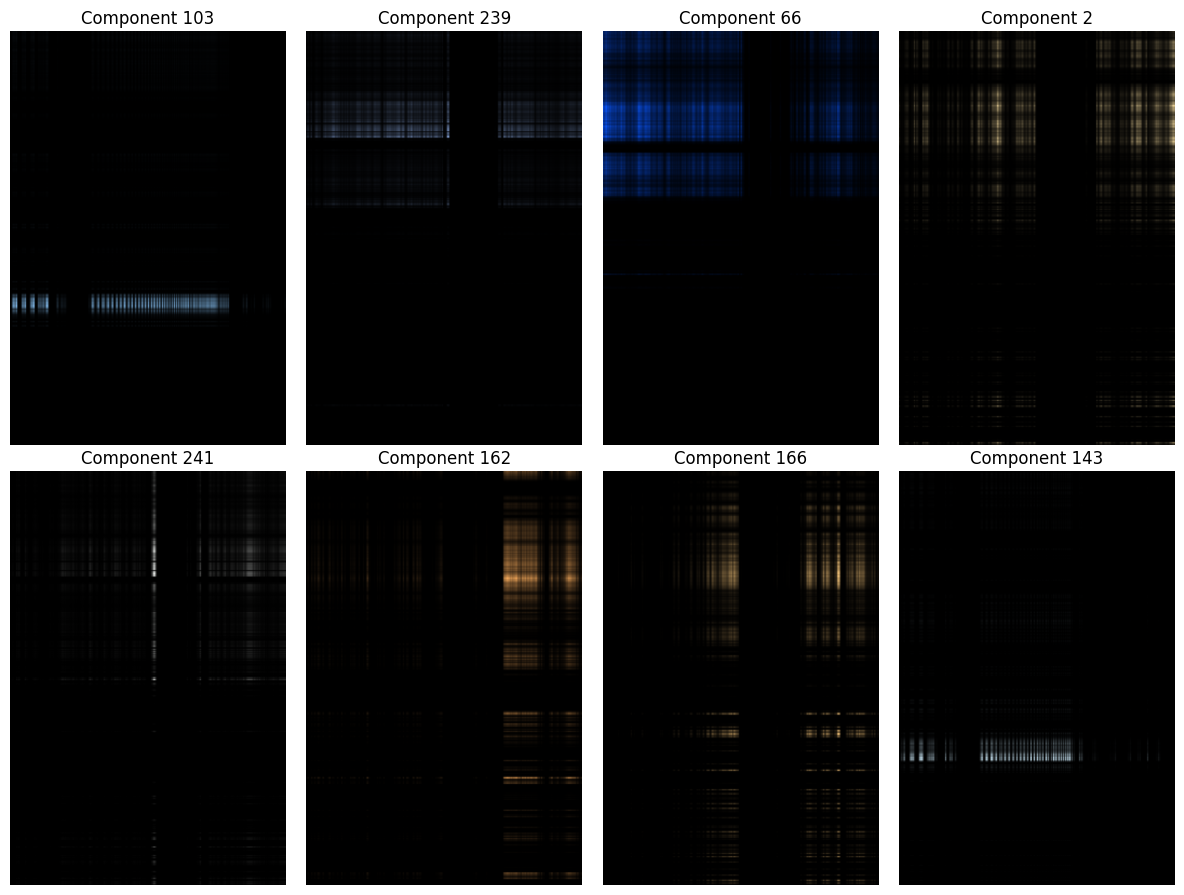

In [9]:
model = fitted["FUTON-Linear-MU"]
with torch.no_grad():
    x = eval_dataset.input.to(device)  # (H, W, 2) grid coordinates
    rows, columns = x[:, 0, 0], x[0, :, 1]
    responses = [
        model.basis.axis_features(u, c) @ linear.weight.T
        for c, (u, linear) in enumerate(zip((rows, columns), model.combiner.linears))
    ]
    weight = model.decoder.weight  # (3, R)
    strength = responses[0].sum(0) * responses[1].sum(0) * weight.sum(0)
    chosen = strength.topk(8).indices
    parts = torch.einsum(
        "hr,wr,dr->rhwd",
        responses[0][:, chosen],
        responses[1][:, chosen],
        weight[:, chosen],
    )

fig, axes = plt.subplots(2, 4, figsize=(12, 9))
for ax, index, part in zip(axes.flat, chosen.tolist(), parts):
    ax.imshow((part / part.max()).cpu())
    ax.set_title(f"Component {index}")
    ax.axis("off")

plt.tight_layout()
plt.show()